<a href="https://colab.research.google.com/github/mp371366/ML/blob/main/Charts_in_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 01

## PCA

Saving PCA_three_clusters_data.csv to PCA_three_clusters_data.csv


/tmp/ipykernel_324/3280437752.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_categories)  # tab10 works for up to 10 classes
/tmp/ipykernel_324/3280437752.py:35: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=color_map[cat], label=cat)


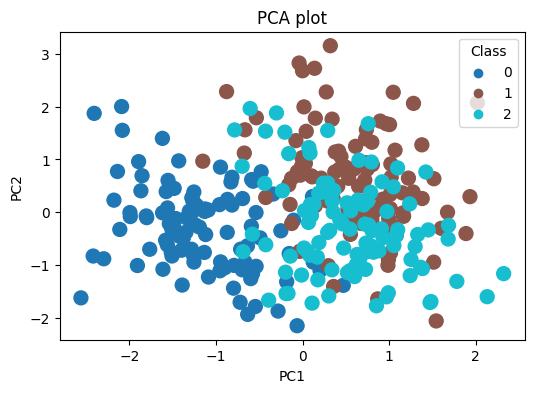

In [2]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

X = df[['x', 'y', 'z']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2']
)

categories = df['class'].unique()
num_categories = len(categories)
cmap = cm.get_cmap('tab10', num_categories)  # tab10 works for up to 10 classes
color_map = {cat: cmap(i) for i, cat in enumerate(categories)}

plt.figure(figsize=(6, 4))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=df['class'].map(color_map), s=100)

for cat in categories:
    plt.scatter([], [], c=color_map[cat], label=cat)
plt.legend(title='Class')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA plot')
plt.show()


## Plot `x` and `y`

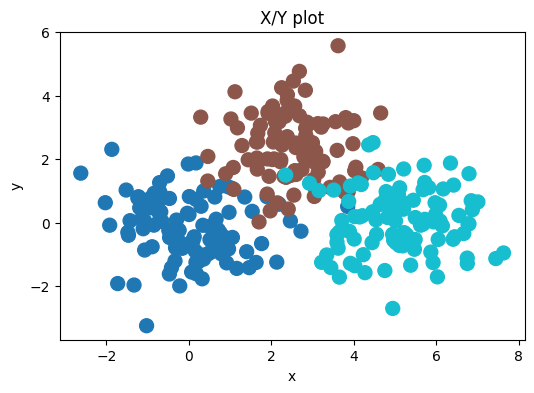

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(df['x'], df['y'], c=df['class'].map(color_map), s=100)

plt.xlabel('x')
plt.ylabel('y')
plt.title('X/Y plot')
plt.show()

## Plot `y` and `z`

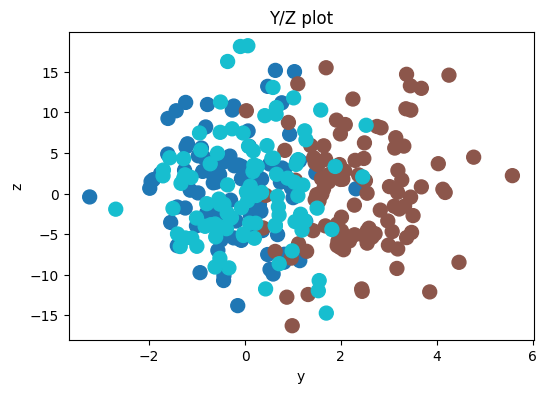

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(df['y'], df['z'], c=df['class'].map(color_map), s=100)

plt.xlabel('y')
plt.ylabel('z')
plt.title('Y/Z plot')
plt.show()

## Plot `z` and `x`

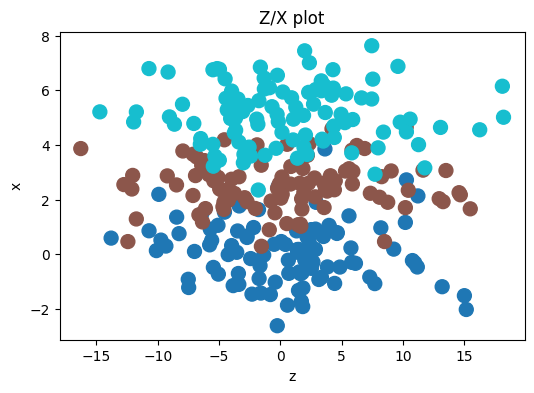

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(df['z'], df['x'], c=df['class'].map(color_map), s=100)

plt.xlabel('z')
plt.ylabel('x')
plt.title('Z/X plot')
plt.show()

## Conclusions

PCA perform worse than `x`/`y` plot and `z`/`x` plot in sense of visual separation of classes and better than `y`/`z` plot in this sense. It is becouse PCA does not know about hidden classes, it only choose PC to maximize variance of the data in those directions.

Also we can notice that variance of the data in PCA plot and other plots differ. It is becouse we standarize data for the PCA plot.
We do that so each feature can impact two the length of PCs in the same way.